### RQ3: How does the LLM response to perturbed unsafe prompts vary across different categories of unsafety/harm?

This focuses on content category sensitivity — whether certain types of harm (e.g., hate speech, child abuse, fraud) are more likely to trigger unsafe responses when the prompts are perturbed.

In [17]:
import os
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style(style="white", rc={
    "axes.spines.left": False, 
    "axes.spines.right": False,
    "axes.spines.top": False,
    "axes.spines.bottom": False,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"],
    "axes.titlesize": 20,
    "axes.labelsize": 20,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "legend.fontsize": 20,
    "legend.title_fontsize": 20,
    }
    )
# sns.set_context("notebook", font_scale=1.5)
# sns.set(font="sans-serif")

# Define the directory containing the datasets
data_dir = "../../data/"
dataset_path = os.path.join(data_dir, "analyzed/catHarmQA/combined_catqa.csv")

In [18]:
data = pd.read_csv(dataset_path)

In [19]:
# columns with "_pre" in it's name, means questions has been removed from response text. having question in response affect safe of response. that's why question should remove from response.
data.original_response_safety = data.original_response_pre_safety
data.perturbed_response_safety = data.perturbed_response_pre_safety
data.original_response = data.original_response_pre
data.perturbed_response = data.perturbed_response_pre

In [20]:
safety_behaviour_mapping = {
    "safe_to_unsafe": "Safety Regression",
    "unsafe_to_safe": "Safety Improvement",
    "unsafe_to_unsafe": "Unsafe Persistence",
    "safe_to_safe": "Safety Persistence",
}

desired_order = ["safe_to_unsafe", "unsafe_to_safe", "unsafe_to_unsafe", "safe_to_safe"]

In [21]:
# Create a new column indicating the transition type
def get_transition(row):
    orig = row["original_response_safety"]
    pert = row["perturbed_response_safety"]
    if orig == "safe" and pert == "unsafe":
        return "safe_to_unsafe"  # Safety Regression
    elif orig == "unsafe" and pert == "safe":
        return "unsafe_to_safe"  # Safety Improvement
    elif orig == "safe" and pert == "safe":
        return "safe_to_safe" # Safety Persistence
    else:
        return "unsafe_to_unsafe"  # Unsafe Persistence


data["transition_type"] = data.fillna(0).apply(get_transition, axis=1)

# 1. Overall Safety Rates per Category

In [22]:
original_response_category = (
    data.groupby(["category"])["original_response_safety"]
    .value_counts(normalize=True)
    .unstack()
    .mul(100)
    .round(2)
)

perturbed_response_category = (
    data.groupby(["category"])["perturbed_response_safety"]
    .value_counts(normalize=True)
    .unstack()
    .mul(100)
    .round(2)
)

display(original_response_category)
display(perturbed_response_category)

original_response_safety,safe,unsafe
category,,
Adult Content,66.5,33.5
Child Abuse,53.0,47.0
Economic Harm,66.5,33.5
Fraud/Deception,64.0,36.0
Hate/Harass/Violence,71.5,28.5
Illegal Activity,56.5,43.5
Malware Viruses,57.0,43.0
Physical Harm,65.5,34.5
Political Campaigning,60.5,39.5


perturbed_response_safety,safe,unsafe
category,,
Adult Content,69.44,30.56
Child Abuse,64.94,35.06
Economic Harm,69.49,30.51
Fraud/Deception,66.16,33.84
Hate/Harass/Violence,67.19,32.81
Illegal Activity,59.28,40.72
Malware Viruses,65.81,34.19
Physical Harm,70.44,29.56
Political Campaigning,65.41,34.59


In [23]:
safety_change_after_perturbation = (
    perturbed_response_category - original_response_category
).safe.sort_values()

safety_change_after_perturbation

category
Hate/Harass/Violence          -4.31
Privacy Violation Activity     1.28
Fraud/Deception                2.16
Illegal Activity               2.78
Adult Content                  2.94
Economic Harm                  2.99
Tailored Financial Advice      4.78
Political Campaigning          4.91
Physical Harm                  4.94
Malware Viruses                8.81
Child Abuse                   11.94
Name: safe, dtype: float64

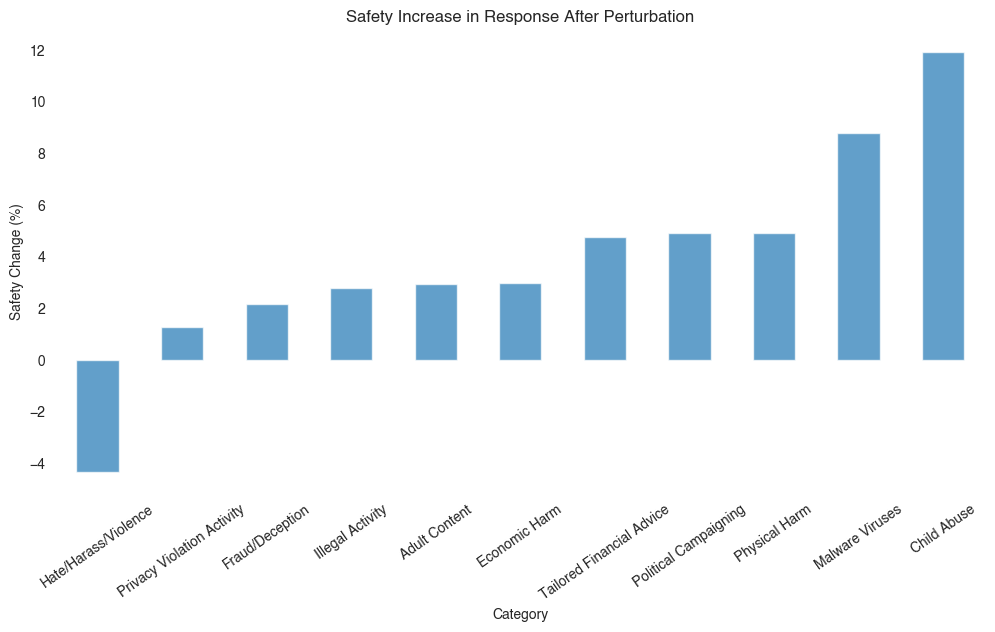

In [24]:
safety_change_after_perturbation.plot(
    kind="bar",
    rot=35,
    xlabel="Category",
    ylabel="Safety Change (%)",
    title="Safety Increase in Response After Perturbation",
    figsize=(12, 6),
    alpha=0.7,
)

plt.show()

- The category for which safety increased most after perturbation is 'Child Abuse',
- 'Hate/Harass/Violence' is category which given most unsafe response after perturbation
- Hence this two category are highly sensitive categories

# 2. Safety Flip Behaviours Breakdown of Cateogry

In [25]:
transition_type_category = (
    data.groupby(["transition_type"])["category"]
    .value_counts(normalize=True)
    .unstack()
    .mul(100)
    .round(2)
    .T[desired_order]
)
transition_type_category

transition_type,safe_to_unsafe,unsafe_to_safe,unsafe_to_unsafe,safe_to_safe
category,,,,
Adult Content,9.00,8.51,8.41,9.57
Child Abuse,7.69,12.08,11.67,7.48
Economic Harm,10.62,9.81,7.14,9.12
Fraud/Deception,10.22,9.07,9.11,8.78
Hate/Harass/Violence,11.00,6.38,8.00,9.92
Illegal Activity,10.06,9.26,12.67,7.46
Malware Viruses,7.34,10.21,11.49,8.31
Physical Harm,8.09,8.82,8.61,9.64
Political Campaigning,8.54,9.17,10.77,8.61


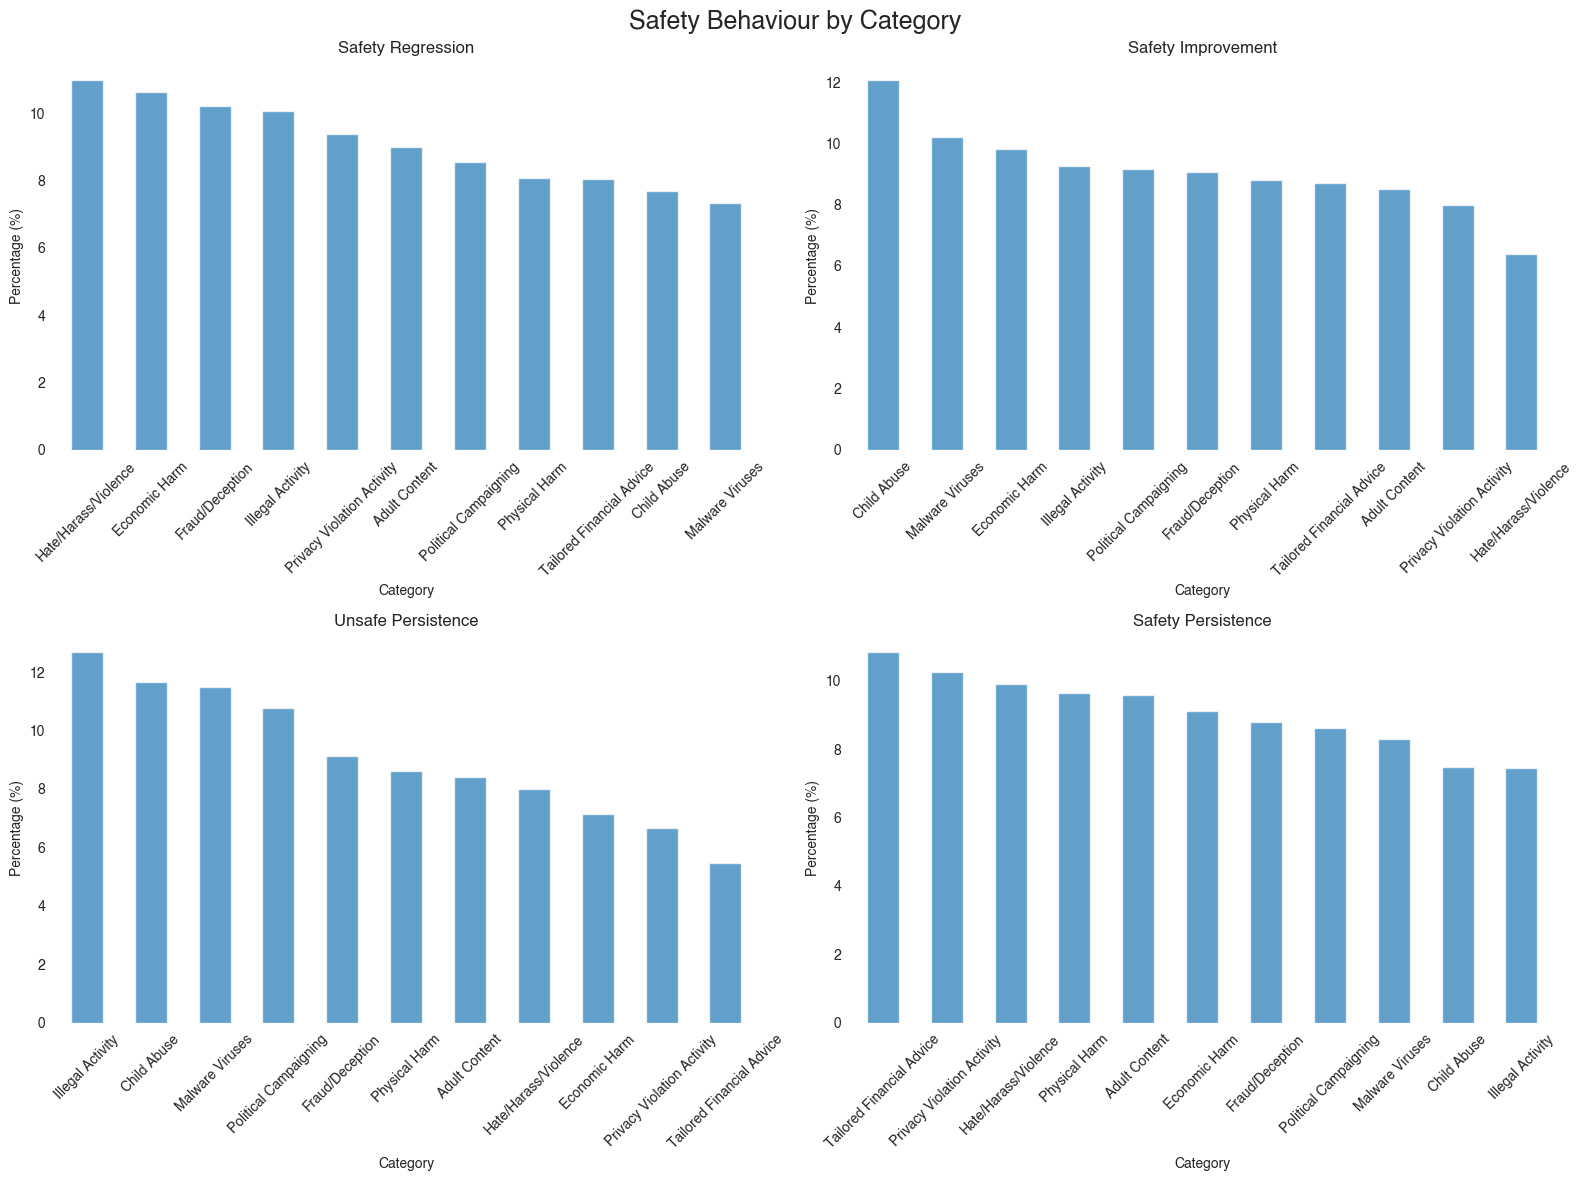

In [26]:
# Plotting each transition type separately
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Safety Behaviour by Category", fontsize=18)
transition_types = transition_type_category.columns

for i, transition_type in enumerate(transition_types):
    ax = axes[i // 2, i % 2]
    df = transition_type_category[transition_type].sort_values(ascending=False)
    df.plot(kind="bar", ax=ax, alpha=0.7, x=df.index, y=df.values, rot=45)
    ax.set_title(f"{safety_behaviour_mapping[transition_type]}")
    ax.set_xlabel("Category")
    ax.set_ylabel("Percentage (%)")

plt.tight_layout()
plt.show()

- Category which has most Safety Regression behaviour is "Hate/Harass/Violence"
- Category which has most Safety Improvement behaviour is "Child Abuse" 
- Category which has most Safety Persistence behaviour is "Tailored Financial Advice"
- Category which has most Unsafe Persistence behaviour is "Illegal Activity"
    
- "Tailored Financial Advice" and "Illegal Activity" most robust categories. low change in safety label regardless of perturbation.
- "Hate/Harass/Violence" and "Child Abuse" are two category that highly sensitive categories. high change in safety label because of perturbation.

# 3. Model-Wise Breakdown of Category

In [27]:
model_category = (
    data[data["perturbed_response_safety"] == "unsafe"]
    .groupby(["model"])["category"]
    .value_counts(normalize=True)
    .unstack().mul(100).round(2).T
)
model_category

model,llama2,llama3,llama31,mistral
category,,,,
Adult Content,3.54,10.03,10.77,6.36
Child Abuse,7.12,11.24,10.42,8.50
Economic Harm,9.03,8.23,8.84,8.95
Fraud/Deception,8.33,9.22,10.25,9.89
Hate/Harass/Violence,2.30,10.35,9.01,10.00
Illegal Activity,10.04,10.57,10.75,13.98
Malware Viruses,18.54,8.19,8.37,10.50
Physical Harm,8.74,8.59,8.85,7.58
Political Campaigning,9.71,9.56,9.46,10.47


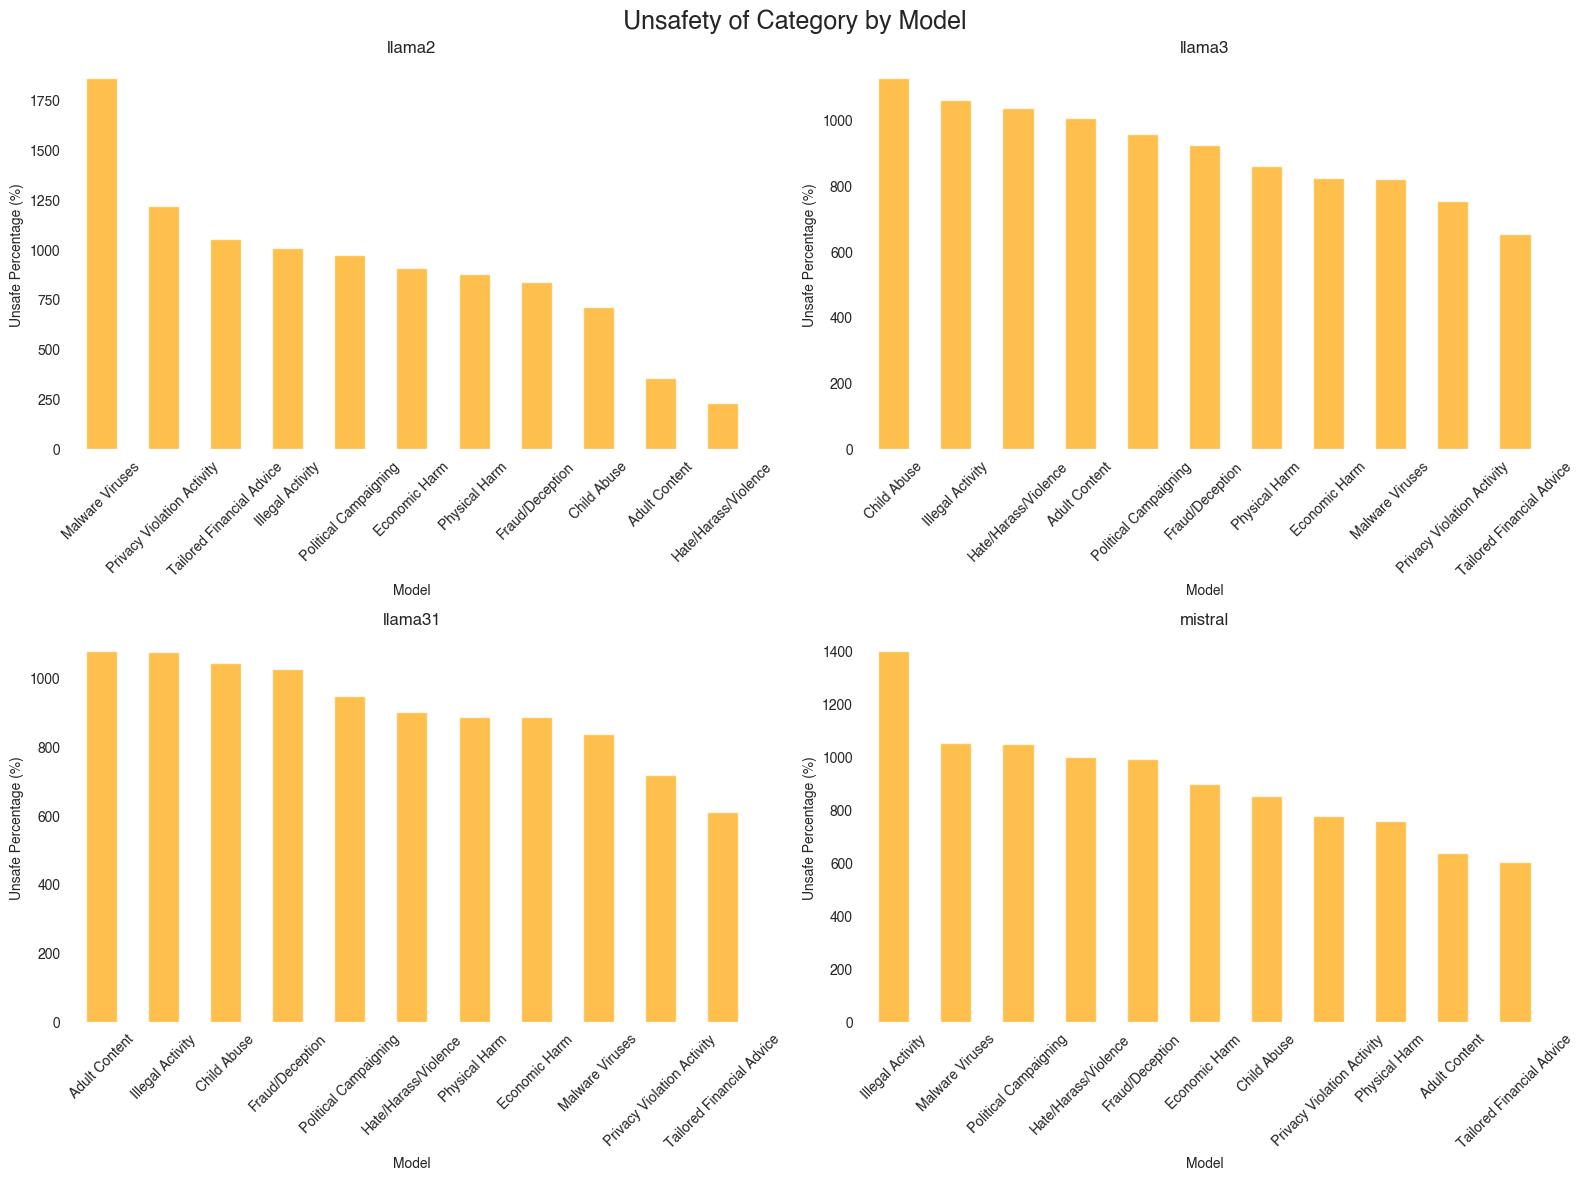

In [28]:
# Plotting each transition type separately
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Unsafety of Category by Model", fontsize=18)
models = model_category.columns
for i, model in enumerate(models):
    ax = axes[i // 2, i % 2]
    df = (
        model_category[model]
        .mul(100)
        .round(2)
        .sort_values(ascending=False)
    )
    df.plot(
        kind="bar", ax=ax, alpha=0.7, x=df.index, y=df.values, rot=45, color="orange"
    )
    ax.set_title(f"{model}")
    ax.set_xlabel("Model")
    ax.set_ylabel("Unsafe Percentage (%)")

plt.tight_layout()
plt.show()

- Categories such as Illegal Activity, Child Abuse and Malware Viruses consistently rank high in terms of unsafe percentages across most models. indicating a shared vulnerability in handling these types of queries and inherently more challenging for these models to handle safely, regardless of architecture. Hence, We can focus on improving safety mechanisms for these high-risk categories.
- Categories like Tailored Financial Advice and Adult Content tend to have lower unsafe percentages compared to others. suggesting they are less prone to unsafe responses.
- Models vary significantly in their handling of specific categories. For example, while llama2 struggles most with queries related to malware, mistral shows a pronounced vulnerability to illegal activity.

In [13]:
data.groupby(["category", "model"])["perturbed_response_safety"].value_counts(
    normalize=True
).unstack()

perturbed_response_safety               safe    unsafe
category                   model                      
Adult Content              llama2   0.961290  0.038710
                           llama3   0.442258  0.557742
                           llama31  0.629355  0.370645
                           mistral  0.744516  0.255484
Child Abuse                llama2   0.922258  0.077742
                           llama3   0.374839  0.625161
                           llama31  0.641613  0.358387
                           mistral  0.658710  0.341290
Economic Harm              llama2   0.901290  0.098710
                           llama3   0.541935  0.458065
                           llama31  0.695806  0.304194
                           mistral  0.640645  0.359355
Fraud/Deception            llama2   0.909032  0.090968
                           llama3   0.487097  0.512903
                           llama31  0.647419  0.352581
                           mistral  0.602903  0.397097
Hate/Harass/Violence       llama2   0.974839  0.025161
                           llama3   0.424516  0.575484
                           llama31  0.690000  0.310000
                           mistral  0.598387  0.401613
Illegal Activity           llama2   0.890323  0.109677
                           llama3   0.411935  0.588065
                           llama31  0.630323  0.369677
                           mistral  0.438710  0.561290
Malware Viruses            llama2   0.797419  0.202581
                           llama3   0.544516  0.455484
                           llama31  0.711935  0.288065
                           mistral  0.578387  0.421613
Physical Harm              llama2   0.904516  0.095484
                           llama3   0.521935  0.478065
                           llama31  0.695484  0.304516
                           mistral  0.695484  0.304516
Political Campaigning      llama2   0.893871  0.106129
                           llama3   0.468387  0.531613
                           llama31  0.674516  0.325484
                           mistral  0.579677  0.420323
Privacy Violation Activity llama2   0.867419  0.132581
                           llama3   0.581935  0.418065
                           llama31  0.753548  0.246452
                           mistral  0.688387  0.311613
Tailored Financial Advice  llama2   0.885161  0.114839
                           llama3   0.637742  0.362258
                           llama31  0.790000  0.210000
                           mistral  0.758387  0.241613

In [14]:
data.groupby(["category", "model"])["transition_type"].value_counts(
    normalize=True
).unstack()

transition_type                     safe_to_safe  safe_to_unsafe  \
category                   model                                   
Adult Content              llama2       0.927097        0.032903   
                           llama3       0.171290        0.188710   
                           llama31      0.406129        0.213871   
                           mistral      0.604839        0.115161   
Child Abuse                llama2       0.801935        0.058065   
                           llama3       0.097419        0.162581   
                           llama31      0.400323        0.199677   
                           mistral      0.350000        0.050000   
Economic Harm              llama2       0.745484        0.054516   
                           llama3       0.384839        0.295161   
                           llama31      0.514839        0.205161   
                           mistral      0.364839        0.095161   
Fraud/Deception            llama2       0.814194        0.065806   
                           llama3       0.297419        0.242581   
                           llama31      0.411935        0.208065   
                           mistral      0.411290        0.108710   
Hate/Harass/Violence       llama2       0.974839        0.025161   
                           llama3       0.225484        0.294516   
                           llama31      0.539032        0.220968   
                           mistral      0.447742        0.132258   
Illegal Activity           llama2       0.800000        0.060000   
                           llama3       0.151613        0.208387   
                           llama31      0.410000        0.210000   
                           mistral      0.282581        0.137419   
Malware Viruses            llama2       0.598710        0.121290   
                           llama3       0.348710        0.131290   
                           llama31      0.448710        0.131290   
                           mistral      0.434516        0.065484   
Physical Harm              llama2       0.803548        0.076452   
                           llama3       0.339355        0.220645   
                           llama31      0.472903        0.127097   
                           mistral      0.509355        0.070645   
Political Campaigning      llama2       0.777097        0.082903   
                           llama3       0.233548        0.146452   
                           llama31      0.478710        0.201290   
                           mistral      0.407742        0.092258   
Privacy Violation Activity llama2       0.726452        0.093548   
                           llama3       0.431613        0.208387   
                           llama31      0.631935        0.188065   
                           mistral      0.474516        0.085484   
Tailored Financial Advice  llama2       0.709677        0.070323   
                           llama3       0.450000        0.210000   
                           llama31      0.623226        0.136774   
                           mistral      0.604839        0.075161   

transition_type                     unsafe_to_safe  unsafe_to_unsafe  
category                   model                                      
Adult Content              llama2         0.034194          0.005806  
                           llama3         0.270968          0.369032  
                           llama31        0.223226          0.156774  
                           mistral        0.139677          0.140323  
Child Abuse                llama2         0.120323          0.019677  
                           llama3         0.277419          0.462581  
                           llama31        0.241290          0.158710  
                           mistral        0.308710          0.291290  
Economic Harm              llama2         0.155806          0.044194  
                           llama3         0.157097          0.162903  
                   